In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from numpy import sum,isrealobj,sqrt
from commpy.filters import rrcosfilter
from numpy.random import standard_normal

In [119]:
bps = 3 
sample_rate = 100
sampling_period = 1/sample_rate
sps = 8  
N = 3000  
Nsym = int(N/bps)  
symbol_period = sampling_period*sps 

size I  Q  C:  1000 1000 1000


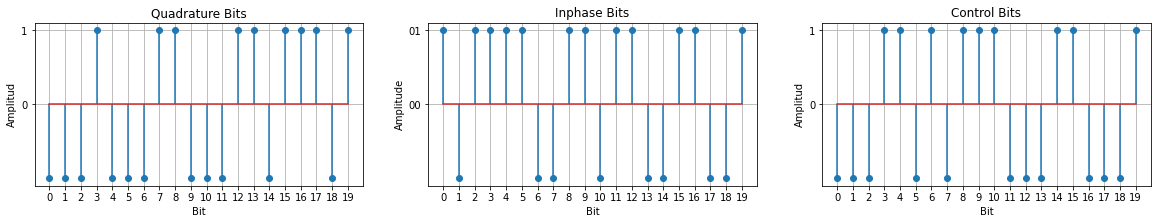

In [120]:

bits=[]
bit = np.random.randint(0, 2, N) 
for i in bit :
    bits.append((2*i-1))
bits=np.array(bits )

i_bits = bits[0::3]  # bits inphase
q_bits = bits[1::3]  # bits quadrature
c_bits = bits[2::3]  # bits control

print("size I  Q  C: ", i_bits.size, q_bits.size, c_bits.size)

fig = plt.figure(figsize=(20, 3))


ax_q = plt.subplot(1,3,1)
ax_q.yaxis.set_ticks(np.arange(0, 11, 1))
ax_q.xaxis.set_ticks(np.arange(0, len(q_bits), 1))
ax_q.set_title("Quadrature Bits")
ax_q.set_xlabel("Bit")
ax_q.set_ylabel("Amplitud")
ax_q.stem(q_bits[0:20], use_line_collection=True)
ax_q.grid(True)

ax_i = plt.subplot(1,3,2)
ax_i.yaxis.set_major_formatter(StrMethodFormatter("{x:02b}"))
ax_i.yaxis.set_ticks(np.arange(0, 11, 1))
ax_i.xaxis.set_ticks(np.arange(0, len(i_bits), 1))
ax_i.set_title("Inphase Bits")
ax_i.grid(True)
ax_i.set_xlabel("Bit")
ax_i.set_ylabel("Amplitude")
ax_i.stem(i_bits[0:20], use_line_collection=True)

ax_c = plt.subplot(1,3,3)
ax_c.yaxis.set_ticks(np.arange(0, 11, 1))
ax_c.xaxis.set_ticks(np.arange(0, len(c_bits), 1))
ax_c.set_title("Control Bits")
ax_c.set_xlabel("Bit")
ax_c.set_ylabel("Amplitud")
ax_c.stem(c_bits[0:20], use_line_collection=True)
ax_c.grid(True)
plt.show()


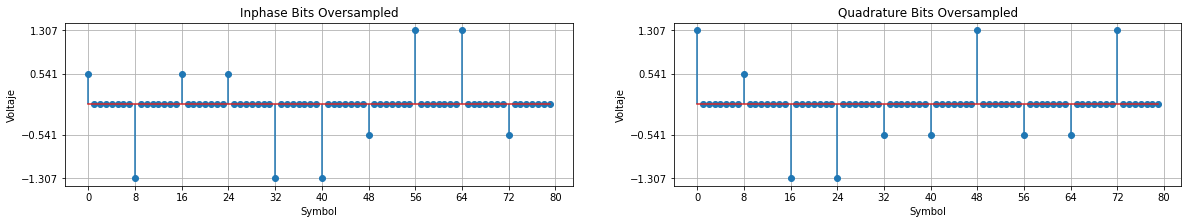

In [121]:

bits = np.random.randint(0, 2, N) 


i_bits = bits[0::3]  # bits inphase
q_bits = bits[1::3]  # bits quadrature
c_bits = bits[2::3]  # bits control
voltage_qc = {}
voltage_qc[(0,0)] = -0.541
voltage_qc[(0,1)] = -1.307
voltage_qc[(1,0)] = 0.541
voltage_qc[(1,1)] = 1.307
voltage_ic = {}
voltage_ic[(0,0)] = -0.541
voltage_ic[(0,1)] = -1.307
voltage_ic[(1,0)] = 0.541
voltage_ic[(1,1)] = 1.307
i_PAM = np.array([])
for index, bit in enumerate(c_bits):
    pulse = np.zeros(sps)  
    pulse[0] = voltage_ic[(i_bits[index], c_bits[index])]  
    i_PAM = np.concatenate((i_PAM, pulse))
q_PAM = np.array([])
for index, bit in enumerate(q_bits):
    pulse = np.zeros(sps)  
    pulse[0] = voltage_qc[(q_bits[index], int(not(c_bits[index])))] 
    q_PAM = np.concatenate((q_PAM, pulse))
fig, (ax_i, ax_q) = plt.subplots(1, 2, figsize=(20, 3))
ax_i.yaxis.set_ticks([-1.307, -0.541, 0.541, 1.307])
ax_i.xaxis.set_ticks(np.arange(0, len(i_PAM), 8))
ax_i.set_title("Inphase Bits Oversampled")
ax_i.grid(True)
ax_i.set_xlabel("Symbol")
ax_i.set_ylabel("Voltaje")
ax_i.stem(i_PAM[0:80], use_line_collection=True)
ax_q.yaxis.set_ticks([-1.307, -0.541, 0.541, 1.307])
ax_q.xaxis.set_ticks(np.arange(0, len(i_PAM), 8))
ax_q.set_title("Quadrature Bits Oversampled")
ax_q.set_xlabel("Symbol")
ax_q.set_ylabel("Voltaje")
ax_q.stem(q_PAM[0:80], use_line_collection=True)
ax_q.grid(True)
plt.show()

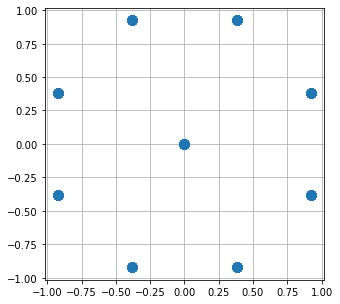

In [122]:
n=[]
for i in range(len (q_PAM)):
    n.append((q_PAM[i]+ 1j*i_PAM[i])/np.sqrt(2) )
plt.figure(figsize=(5, 5))
plt.plot(np.real(n), np.imag(n), '.',markersize=18)
plt.grid(True)

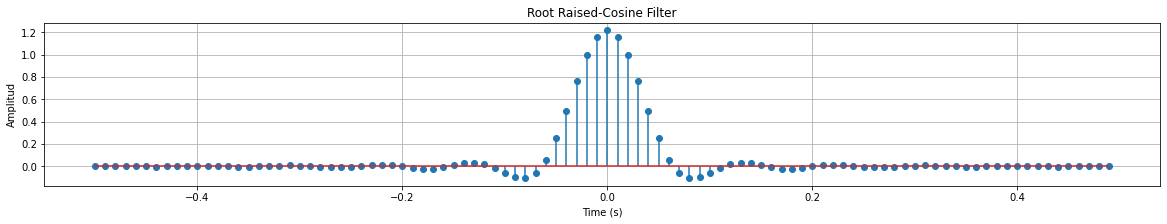

In [123]:


length = 100
beta = 0.8
Tsym = sps*sampling_period

time, filter_response = rrcosfilter(length, beta, Tsym, sample_rate)
plt.figure(figsize=(20, 3))
plt.stem(time, filter_response, use_line_collection=True)
plt.title("Root Raised-Cosine Filter")
plt.xlabel("Time (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

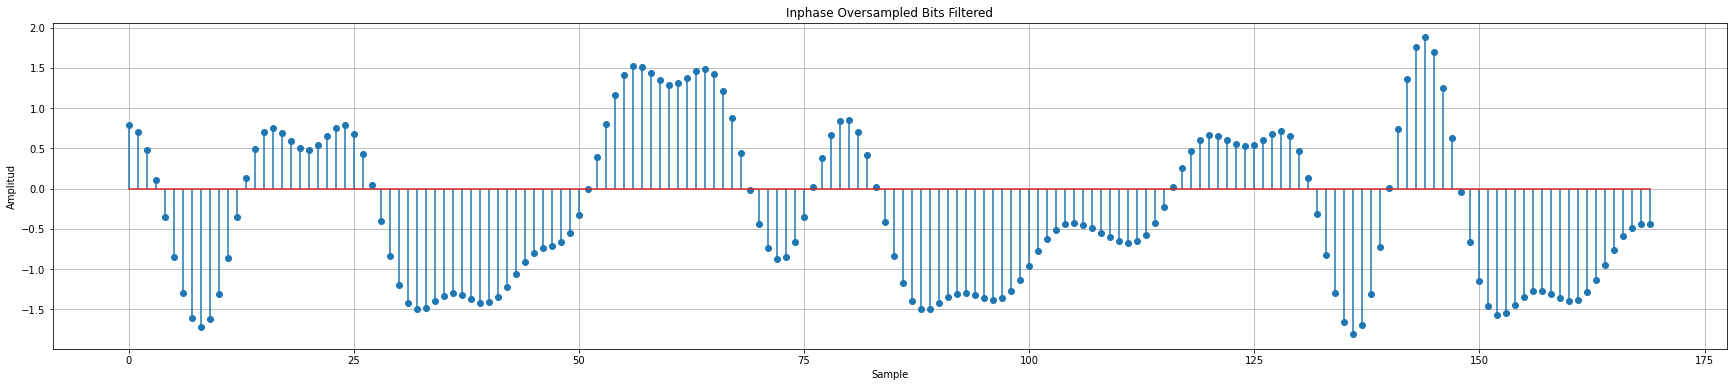

In [124]:
i_filtered = np.convolve(i_PAM, filter_response)
delay = int(length/2)
i_filtered = i_filtered[delay:]  
fig, ax = plt.subplots(figsize=(30, 6))
ax.set_title("Inphase Oversampled Bits Filtered")
ax.grid(True)
ax.set_xlabel("Sample")
ax.set_ylabel("Amplitud")
ax.stem(i_filtered[0:170], use_line_collection=True)
plt.show()

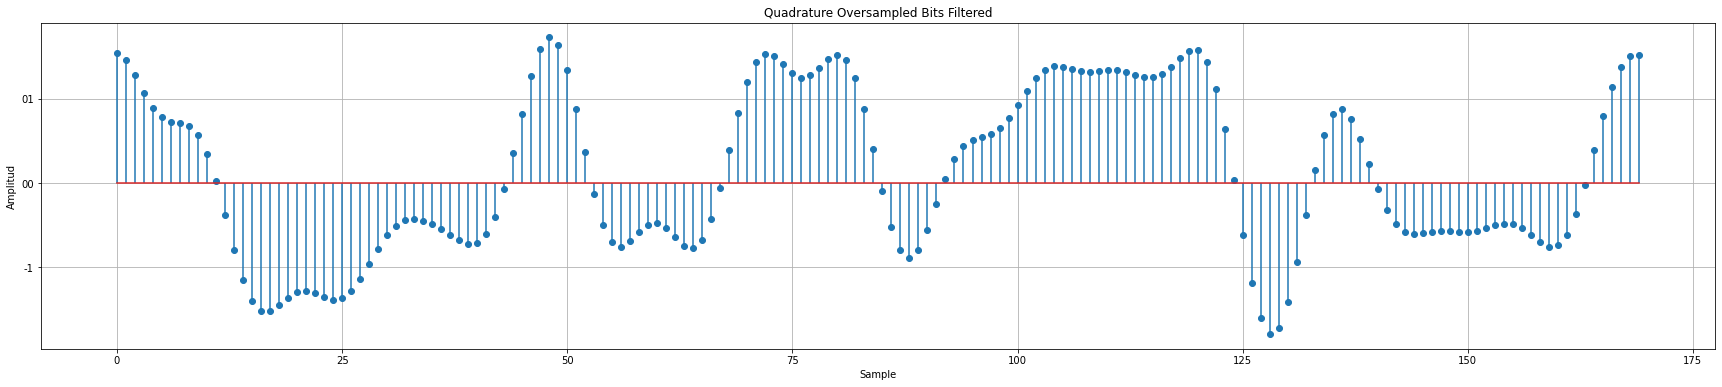

In [125]:
q_filtered = np.convolve(q_PAM, filter_response)
q_filtered = q_filtered[delay:]

fig, ax = plt.subplots(figsize=(30, 6))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:02b}"))
ax.yaxis.set_ticks(np.arange(-11, 11, 1))
ax.set_title("Quadrature Oversampled Bits Filtered")
ax.grid(True)
ax.set_xlabel("Sample")
ax.set_ylabel("Amplitud")
ax.stem(q_filtered[0:170], use_line_collection=True)
plt.show()

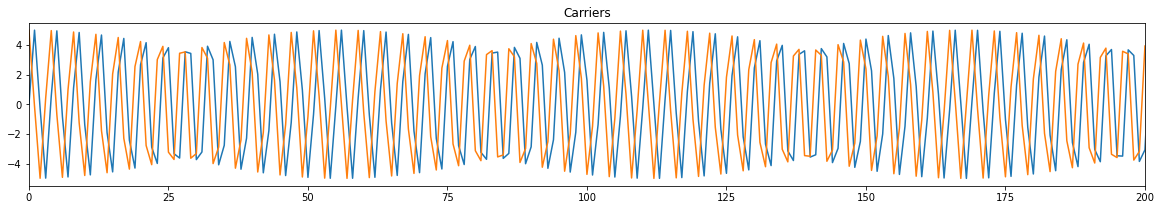

In [127]:
Fc =10e5
t = np.linspace(0, 1, len(i_filtered))

i_carrier = np.sqrt(2/symbol_period)*np.sin((2.0*np.pi*Fc*t))
q_carrier = np.sqrt(2/symbol_period)*np.cos((2.0*np.pi*Fc*t))

plt.figure(figsize=(20, 3))
plt.plot(i_carrier)
plt.plot(q_carrier)
plt.xlim(0, 200)
plt.title("Carriers")
plt.show()

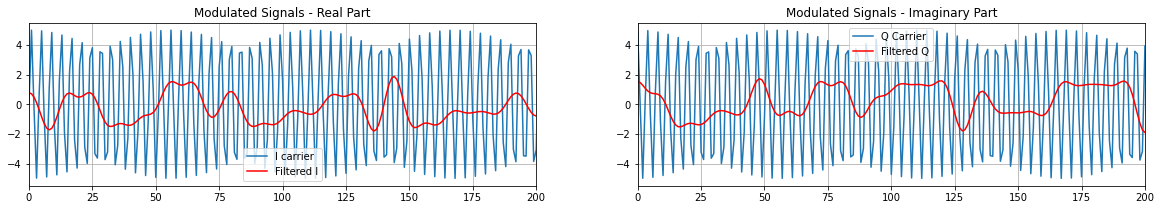

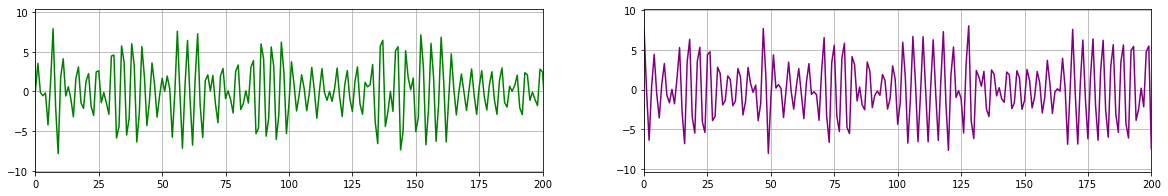

In [128]:
q_modulated = q_filtered * q_carrier
i_modulated = i_filtered * i_carrier

plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(i_carrier, label="I carrier")
plt.plot(i_filtered, label="Filtered I",color="red")
plt.xlim(0, 200)
plt.title("Modulated Signals - Real Part")
plt.grid(True)
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(q_carrier, label="Q Carrier")
plt.plot(q_filtered, label="Filtered Q",color="red")
plt.xlim(0, 200)
plt.title("Modulated Signals - Imaginary Part")
plt.grid(True)
plt.legend()
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(i_modulated,color="green", label="Modulated I")
plt.xlim(0, 200)
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(q_modulated, color="purple", label="Modulated Q")
plt.xlim(0, 200)
plt.grid(True)
plt.show()


In [129]:
signal_modulated = i_modulated + q_modulated

max Doppler shift: 0.67056


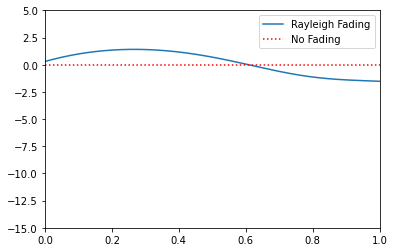

In [141]:
v_mph = 60 # velocity of either TX or RX, in miles per hour
center_freq = 15*1e6 # RF carrier frequency in Hz

Fs =8049 # sample rate of simulation
N = 100 # number of sinusoids to sum

v = v_mph * 0.44704 # convert to m/s
fd = v*center_freq/6e8 # max Doppler shift
print("max Doppler shift:", fd)
t = np.arange(0, 1, 1/Fs) # time vector. (start, stop, step)
x = np.zeros(len(t))
y = np.zeros(len(t))
for i in range(N):
    alpha = (np.random.rand() - 0.5) * 2 * np.pi
    phi = (np.random.rand() - 0.5) * 2 * np.pi
    x = x + np.random.randn() * np.cos(2 * np.pi * fd * t * np.cos(alpha) + phi)
    y = y + np.random.randn() * np.sin(2 * np.pi * fd * t * np.cos(alpha) + phi)

z1 = (1/np.sqrt(N)) * (x + 1j*y) 
z_mag1 = np.abs(z1) # take magnitude for the sake of plotting
z_mag_dB1 = 10*np.log10(z_mag1) # convert to dB

# Plot fading over time
plt.plot(t, z_mag_dB1)
plt.plot([0, 1], [0, 0], ':r') # 0 dB
plt.legend(['Rayleigh Fading', 'No Fading'])
plt.axis([0, 1, -15, 5])
plt.show()


max Doppler shift: 5.0292


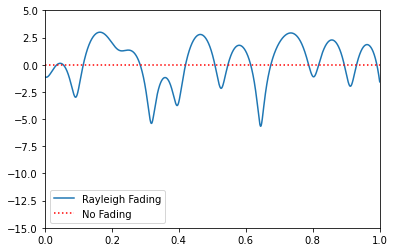

In [29]:

v_mph = 60 # velocity of either TX or RX, in miles per hour
center_freq = 15*1e6 # RF carrier frequency in Hz
Fs = 8049 # sample rate of simulation
N = 100 # number of sinusoids to sum
v = v_mph * 0.44704 # convert to m/s
fd = v*center_freq/8e7 # max Doppler shift
print("max Doppler shift:", fd)
t = np.arange(0, 1, 1/Fs) # time vector. (start, stop, step)
x = np.zeros(len(t))
y = np.zeros(len(t))
for i in range(N):
    alpha = (np.random.rand() - 0.5) * 2 * np.pi
    phi = (np.random.rand() - 0.5) * 2 * np.pi
    x = x + np.random.randn() * np.cos(2 * np.pi * fd * t * np.cos(alpha) + phi)
    y = y + np.random.randn() * np.sin(2 * np.pi * fd * t * np.cos(alpha) + phi)
z2 = (1/np.sqrt(N)) * (x + 1j*y) 
z_mag2 = np.abs(z2) # take magnitude for the sake of plotting
z_mag_dB2 = 10*np.log10(z_mag2) # convert to dB
# Plot fading over time
plt.plot(t, z_mag_dB2)
plt.plot([0, 1], [0, 0], ':r') # 0 dB
plt.legend(['Rayleigh Fading', 'No Fading'])
plt.axis([0, 1, -15, 5])
plt.show()

In [142]:
# AWGN path1
n=np.random.normal(0,1,len(signal_modulated))
noise_power = 1.3
noise1= n * np.sqrt(noise_power)
# AWGN path2
n=np.random.normal(0,1,len(signal_modulated))
noise_power = 1.3
noise2= n * np.sqrt(noise_power)
path2_fading=z_mag2*signal_modulated+noise2*z2.imag
path1_fading=z_mag1*signal_modulated+noise1*z1.imag
recived_signal=path1_fading+path2_fading

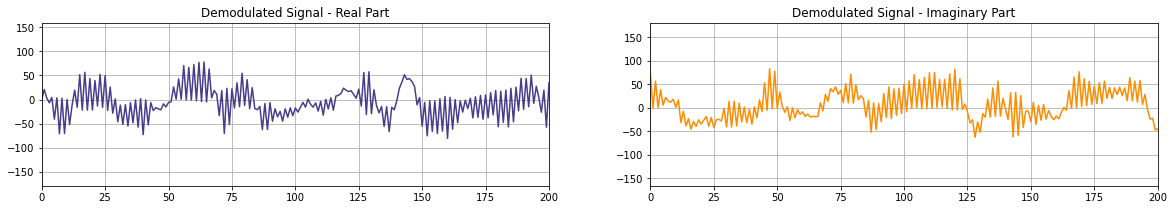

In [143]:
demodulated_i = recived_signal * i_carrier
demodulated_q = recived_signal * q_carrier

plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(demodulated_i, "darkslateblue")
plt.xlim(0, 200)
plt.grid(True)
#plt.ylim(-2, 2)
plt.title("Demodulated Signal - Real Part")
plt.subplot(1, 2, 2)
plt.plot(demodulated_q, "darkorange")
plt.xlim(0, 200)
plt.grid(True)
#plt.ylim(-2, 2)
plt.title("Demodulated Signal - Imaginary Part")
plt.show()


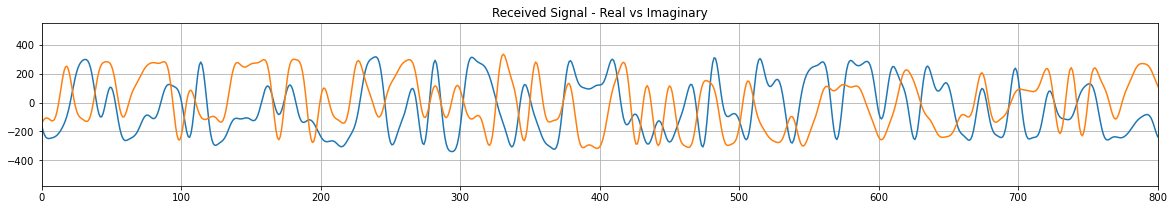

In [144]:
q_filtered_r = np.convolve(demodulated_q, filter_response)
q_filtered_r = q_filtered_r[80:]
i_filtered_r = np.convolve(demodulated_i, filter_response)
i_filtered_r = i_filtered_r[80:]
t = np.arange(len(i_filtered_r))

plt.figure(figsize=(20, 3))
plt.plot(t, i_filtered_r, q_filtered_r)
plt.xlim(0, 800)
plt.title("Received Signal - Real vs Imaginary")
plt.grid(True)
plt.show()


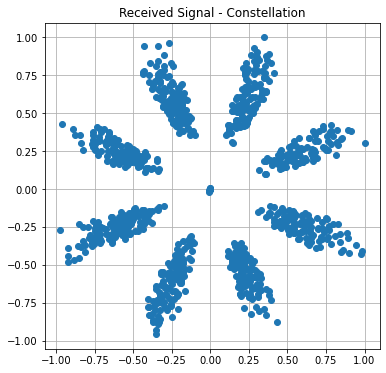

In [163]:
time_offset = 3

i_sampled = np.array([])
q_sampled = np.array([])
i_sampled = i_filtered_r

i_sampled = i_sampled[time_offset:]
i_sampled = i_sampled[sps::sps]
q_sampled = q_filtered_r
q_sampled = q_sampled[time_offset:]
q_sampled = q_sampled[sps::sps]


plt.figure(figsize=(6, 6))
plt.plot(i_sampled/max(i_sampled), q_sampled/max(q_sampled), 'o')
plt.title("Received Signal - Constellation")
plt.grid(True)
plt.show()


In [146]:
phase_vector = np.array([])
estimated_q = np.array([])
estimated_i = np.array([])
estimated_c = np.array([])

for i in range(0, len(i_filtered_r), sps):  # range(start, stop, step):
    phase = int(np.arctan2(q_filtered_r[i], i_filtered_r[i])*180/np.pi)
    phase_vector = np.append(phase_vector, phase)
    if phase in range(0, 45):
        estimated_q = np.append(estimated_q, 1)
        estimated_i = np.append(estimated_i, 1)
        estimated_c = np.append(estimated_c, 1)
    elif phase in range(45, 90):
        estimated_q = np.append(estimated_q, 1)
        estimated_i = np.append(estimated_i, 1)
        estimated_c = np.append(estimated_c, 0)
    elif phase in range(90, 135):
        estimated_q = np.append(estimated_q, 1)
        estimated_i = np.append(estimated_i, 0)
        estimated_c = np.append(estimated_c, 0)
    elif phase in range(135, 180):
        estimated_q = np.append(estimated_q, 1)
        estimated_i = np.append(estimated_i, 0)
        estimated_c = np.append(estimated_c, 1)
    elif phase in range(-180, -135):
        estimated_q = np.append(estimated_q, 0)
        estimated_i = np.append(estimated_i, 0)
        estimated_c = np.append(estimated_c, 1)
    elif phase in range(-135, -90):
        estimated_q = np.append(estimated_q, 0)
        estimated_i = np.append(estimated_i, 0)
        estimated_c = np.append(estimated_c, 0)
    elif phase in range(-90, -45):
        estimated_q = np.append(estimated_q, 0)
        estimated_i = np.append(estimated_i, 1)
        estimated_c = np.append(estimated_c, 0)
    elif phase in range(-45, 0):
        estimated_q = np.append(estimated_q, 0)
        estimated_i = np.append(estimated_i, 1)
        estimated_c = np.append(estimated_c, 1)

symbol_error = 0
bit_error = 0

for i in range(0, len(i_bits)):
    sym_error_aux = 0
    if i_bits[i] != estimated_i[i]:
        bit_error += 1
        sym_error_aux += 1
    if q_bits[i] != estimated_q[i]:
        bit_error += 1
        sym_error_aux += 1
    if c_bits[i] != estimated_c[i]:
        bit_error += 1
        sym_error_aux += 1
    
    if sym_error_aux > 0:
        symbol_error += 1
N=50000
BER = (bit_error/N)*100
SER = (symbol_error/Nsym)

print("BER: {:.2f}%".format(BER))


BER: 2.94%


<Figure size 432x288 with 0 Axes>

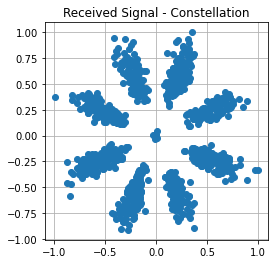

<Figure size 432x288 with 0 Axes>

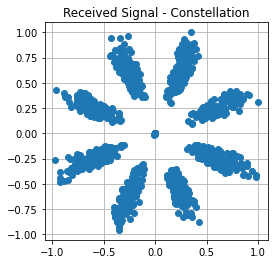

In [149]:
snrdb=np.arange(0,20,10)
for i in snrdb:
    snr=10**(i/10)
    n=np.random.normal(0,1,len(signal_modulated))
    noise_power = 1/(snr**2)
    noise1= n * np.sqrt(noise_power)
    # AWGN path2
    n=np.random.normal(0,1,len(signal_modulated))
    noise_power = 1/snr
    noise2= n * np.sqrt(noise_power)
    path2_fading=z_mag2*signal_modulated+noise2*z2.imag
    path1_fading=z_mag1*signal_modulated+noise1*z1.imag
    recived_signal=path1_fading+path2_fading
    demodulated_i = recived_signal * i_carrier
    demodulated_q = recived_signal * q_carrier
    q_filtered_r = np.convolve(demodulated_q, filter_response)
    q_filtered_r = q_filtered_r[80:]
    i_filtered_r = np.convolve(demodulated_i, filter_response)
    i_filtered_r = i_filtered_r[80:]
    time_offset = 3

    i_sampled = np.array([])
    q_sampled = np.array([])
    i_sampled = i_filtered_r

    i_sampled = i_sampled[time_offset:]
    i_sampled = i_sampled[sps::sps]
    q_sampled = q_filtered_r
    q_sampled = q_sampled[time_offset:]
    q_sampled = q_sampled[sps::sps]
    plt.figure(i)
    plt.figure(figsize=(4,4))
    plt.plot(i_sampled/max(i_sampled), q_sampled/max(q_sampled), 'o')
    plt.title("Received Signal - Constellation")
    plt.grid(True)
    plt.show()

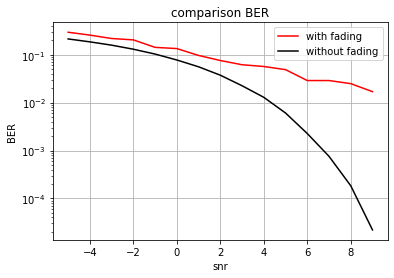

In [14]:
import random
import numpy as np
import matplotlib.pyplot as plt
from numpy import matlib as mb
erpr=[]
iteration=int(10**3)
snrdb=np.arange(start=-5, stop=10, step=1)
simsnr=10**(snrdb/10)
for j in range(1,len(snrdb)+1):
    snr=10**(snrdb[j-1]/10)
    count=0
    for i in range (1,iteration):
        mu = 0
        sigma = np.sqrt(0.5)
        #generating sending bits matrix
        x=np.round(random.random())
        x_bits=2*x-1
        #generating fading coefficient matrix
        H=(sigma*complex(random.random(), random.random()))
        #generate noise matrix
        noise=random.random()
        received=(np.sqrt(0.5)*noise)+ (np.sqrt(snr)*abs(H)*x_bits)
        if received >=0:
            detected=1
        else:
            detected=0
        if ((detected==0 and x==1)or(detected==1 and x==0)):
            count=count+1
    erpr.append(count/iteration)
import random
from numpy import sqrt
from numpy.random import rand, randn
N = 500000
EbNodB_range = range(-5,10)
itr = len(EbNodB_range)
ber = [None]*itr
for n in range (0, len(EbNodB_range)): 
    EbNodB = EbNodB_range[n]   
    EbNo=10.0**(EbNodB/10.0)
    x = 2 * (rand(N) >= 0.5) - 1
    noise_std = 1/sqrt(2*EbNo)
    y = x + noise_std * randn(N)
    y_d = 2 * (y >= 0) - 1
    errors = (x != y_d).sum()
    ber[n] =  errors / N
plt.plot(snrdb,erpr,'r',label ='with fading')   

plt.plot(EbNodB_range, ber, 'k',label ='without fading')
plt.xscale('linear')
plt.yscale('log')
plt.xlabel('snr')
plt.ylabel('BER')
plt.legend()
plt.grid(True)
plt.title('comparison BER')
plt.show() 


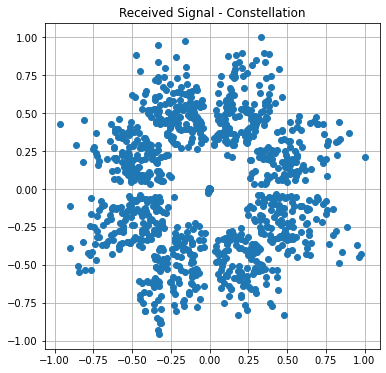

In [164]:
time_offset = 4

i_sampled = np.array([])
q_sampled = np.array([])
i_sampled = i_filtered_r

i_sampled = i_sampled[time_offset:]
i_sampled = i_sampled[sps::sps]
q_sampled = q_filtered_r
q_sampled = q_sampled[time_offset:]
q_sampled = q_sampled[sps::sps]


plt.figure(figsize=(6, 6))
plt.plot(i_sampled/max(i_sampled), q_sampled/max(q_sampled), 'o')
plt.title("Received Signal - Constellation")
plt.grid(True)
plt.show()